In [329]:
import pyreadstat as rs
import os
import DE_Utilities as DE
import numpy as np

In [292]:
data = rs.read_xport("SMQ_L.xpt")

In [293]:
# DE.xpt_to_csv("datasets" , "datasets_csv")

In [294]:
# DE.join_datasets("datasets_csv" , output_dir = "silver" , first_file="ACQ_L.csv" , join_on='SEQN')

In [295]:
import pandas as pd 

In [296]:
df = pd.read_csv("datasets_csv/HIQ_L.csv")

In [297]:
df_2 = pd.read_csv("datasets_csv/HSQ_L.csv")

In [298]:
df.columns

Index(['Unnamed: 0', 'SEQN', 'HIQ011', 'HIQ032A', 'HIQ032B', 'HIQ032C',
       'HIQ032D', 'HIQ032E', 'HIQ032F', 'HIQ032H', 'HIQ032I', 'HIQ210'],
      dtype='str')

In [299]:
df.merge(df_2 , on = "SEQN" , how = "outer")

,Unnamed: 0_x,SEQN,HIQ011,HIQ032A,HIQ032B,HIQ032C,HIQ032D,HIQ032E,HIQ032F,HIQ032H,HIQ032I,HIQ210,Unnamed: 0_y,HSQ590
0,0,130378.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,NaN
1,1,130379.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0
2,2,130380.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,1.0,2.0,1.0
3,3,130381.0,1.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,4,130382.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11928,11928,142306.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11929,11929,142307.0,1.0,NaN,2.0,NaN,4.0,NaN,NaN,NaN,NaN,2.0,6611.0,1.0
11930,11930,142308.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,6612.0,2.0
11931,11931,142309.0,1.0,1.0,NaN,NaN,NaN,NaN,6.0,NaN,NaN,2.0,6613.0,1.0


In [300]:
df = pd.read_csv("silver/final_data.csv")

In [301]:
df = df.select_dtypes(exclude="str")

In [302]:
m , n = df.shape

In [303]:
m

11933

In [304]:
fil = (df > 0).astype("int").sum(axis = 0) > 0.80 * m

In [305]:
cols = df.loc[: , fil].columns

In [306]:
required_cols = ['BPQ020' , 'RIAGENDR' , "RIDAGEYR"  , "BMXBMI", "PAD790Q" , "DIQ010" , "DR1TSODI" ] 
required_cols_mapping = ["had_hypertension" , "gender" , "age_at_years"   , "Body_Mass_Index"   , "Frequency_of_moderate_LTPA" , "had_diabetes"  , "Sodium_(mg)_perday"]

In [307]:
df_f_v_1 = df.loc[: , required_cols]

In [308]:
df_f_v_1.columns = required_cols_mapping

In [309]:
df_f_v_2 = df_f_v_1[~df_f_v_1.had_hypertension.isna()]

In [310]:
df_f_v_3 = df_f_v_2

In [311]:
BMI_mean = df_f_v_3.Body_Mass_Index.mean()

In [312]:
df_f_v_4 = df_f_v_3.fillna(BMI_mean)

In [343]:
df_f_v_5 = df_f_v_4[(df_f_v_4.had_hypertension == 1.0) | (df_f_v_4.had_hypertension == 2.0)]


In [344]:
df_f_v_5.had_hypertension = df_f_v_5.had_hypertension.apply(lambda row : 1 if row == 1.0 else 0)
df_f_v_5.gender = df_f_v_5.gender.apply(lambda row : 1 if row == 1.0 else 0)

In [345]:
df_f_v_6 = df_f_v_5.loc[(df_f_v_5.had_diabetes == 1.0)|(df_f_v_5.had_diabetes == 2.0)]

In [346]:
df_f_v_6.had_diabetes = df_f_v_6.had_diabetes.apply(lambda row : 1 if row == 1.0 else 0)

In [347]:
df_f_v_7 = df_f_v_6.rename(columns = {"had_hypertension" : "target"})

In [348]:
df_f_v_7

,target,gender,age_at_years,Body_Mass_Index,Frequency_of_moderate_LTPA,had_diabetes,Sodium_(mg)_perday
0,1,1,43.0,27.000000,3.0,0,2628.000000
1,1,1,66.0,33.500000,4.0,0,5635.000000
2,0,0,44.0,29.700000,1.0,1,2890.000000
6,0,1,43.0,29.465971,0.0,0,29.465971
7,0,0,65.0,29.465971,1.0,0,29.465971
...,...,...,...,...,...,...,...
11925,0,0,69.0,27.900000,2.0,1,342.000000
11929,0,0,49.0,29.465971,3.0,1,3014.000000
11930,0,1,50.0,26.400000,1.0,0,29.465971
11931,0,1,40.0,25.500000,2.0,0,9476.000000


In [422]:
min_target = df_f_v_7.groupby('target').count().gender.min()

class_1 = df_f_v_7.loc[df_f_v_7.target == 1].iloc[:min_target]
class_0 = df_f_v_7.loc[df_f_v_7.target == 0].iloc[:min_target]

df_f_v_final = pd.concat([class_1 , class_0]).astype("float")

In [425]:
cols = df_f_v_final.columns[1:]
for col in cols:
    mean_value = df_f_v_final.loc[: , col].mean()
    max_value = df_f_v_final.loc[: , col].max()
    min_value = df_f_v_final.loc[: , col].min()
    
    result = (df_f_v_final.loc[: , col] - np.array(mean_value))/(np.array(max_value) - np.array(min_value))
    df_f_v_final.loc[: , col] = result

In [426]:
df_f_v_final

,target,gender,age_at_years,Body_Mass_Index,Frequency_of_moderate_LTPA,had_diabetes,Sodium_(mg)_perday
0,1.0,0.536033,-0.159269,-0.047196,-0.004775,-0.166786,0.050168
1,1.0,0.536033,0.200106,0.061864,-0.004675,-0.166786,0.256085
9,1.0,-0.463967,0.231356,0.214549,-0.005075,-0.166786,0.301212
10,1.0,-0.463967,-0.409269,0.233005,-0.004575,-0.166786,-0.127777
11,1.0,0.536033,0.090731,-0.030418,-0.004775,-0.166786,0.108581
...,...,...,...,...,...,...,...
6239,0.0,0.536033,-0.581144,-0.146190,-0.002128,-0.166786,-0.009340
6244,0.0,-0.463967,0.090731,-0.005821,-0.004775,-0.166786,-0.127777
6245,0.0,0.536033,0.012606,-0.055586,-0.004975,-0.166786,0.014764
6247,0.0,-0.463967,-0.393644,0.134012,-0.004575,-0.166786,0.242800


In [427]:
X = df_f_v_final.iloc[: , 1:]
Y = df_f_v_final.iloc[: , 0]

In [ ]:
def transform(df):
    required_cols = ['BPQ020' , 'RIAGENDR' , "RIDAGEYR"  , "BMXBMI", "PAD790Q" , "DIQ010" , "DR1TSODI" ] 
    required_cols_mapping = ["had_hypertension" , "gender" , "age_at_years"   , "Body_Mass_Index"   , "Frequency_of_moderate_LTPA" , "had_diabetes"  , "Sodium_(mg)_perday"]
    df_f_v_1 = df.loc[: , required_cols]
    df_f_v_1.columns = required_cols_mapping
    df_f_v_2 = df_f_v_1[~df_f_v_1.had_hypertension.isna()]
    df_f_v_3 = df_f_v_2
    BMI_mean = df_f_v_3.Body_Mass_Index.mean()
    df_f_v_4 = df_f_v_3.fillna(BMI_mean)
    df_f_v_5 = df_f_v_4[(df_f_v_4.had_hypertension == 1.0) | (df_f_v_4.had_hypertension == 2.0)]
    df_f_v_5.had_hypertension = df_f_v_5.had_hypertension.apply(lambda row : 1 if row == 1.0 else 0)
    df_f_v_5.gender = df_f_v_5.gender.apply(lambda row : 1 if row == 1.0 else 0)
    df_f_v_6 = df_f_v_5.loc[(df_f_v_5.had_diabetes == 1.0)|(df_f_v_5.had_diabetes == 2.0)]
    df_f_v_6.had_diabetes = df_f_v_6.had_diabetes.apply(lambda row : 1 if row == 1.0 else 0)
    df_f_v_final = df_f_v_6.rename(columns = {"had_hypertension" : "target"})
    X = df_f_v_final.iloc[: , 1:]
    Y = df_f_v_final.iloc[: , 0]

    return df_f_v_final , X , Y
    


In [ ]:
def load(destinations , data):
    
    if len(destinations) != len(data):
        logger.error("The length of destinations is not equal to length of data")
        return None
    logger.info(f"The data is being loaded to destinations")
    try:
        i = 0 
        while i < len(destinations):
            df = data[i]
            dest = destinations[i]
            df.to_csv(dest)
            i +=1
        logger.info(f"The data has been loaded to destinations successfully")
    except Exception as e:
        logger.error(f"The data hasn't been loaded successfully , Error : {e}")
    return None

    

In [457]:
class Logistic_regression_model:
    def __init__(self , X , Y , learning_rate = .1 , EPOCHS = 3000):
        self.X = X
        self.Y = Y
        self.learning_rate = learning_rate
        self.EPOCHS = EPOCHS
        self.W = None
        self.b = None
        self.costs = []
    
    def sigmoid(self , Z):
        g = 1 /(1 + np.exp(-1 * Z))
        return g

    def initialize(self):
        m , n = self.X.shape
        W = np.random.randn(1 , n)
        b = 0
        return W , b
           
    def compute_linear(self , W , b , X):
        Z = np.dot(W , X.T) + b
        g = self.sigmoid(Z)

        return g
    
    def cost(self , g):
        m , n = self.X.shape
        Y = self.Y.T
        loss = Y * np.log(g) + (1 - Y) * np.log(1 - g)

        cost_v = float((-1/m) * np.sum(loss))

        return cost_v
    
    def derivatives(self , g):
        m , n = self.X.shape

        dW = (1/m) * np.dot(g - self.Y.T , self.X)
        db = (1/m) * np.sum(g - self.Y.T)

        return dW , db
    

    def update(self , dW, db):
        
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db
    def fit(self):
        self.W , self.b = self.initialize()

        for _ in range(self.EPOCHS):
            g = self.compute_linear(self.W , self.b , self.X)
            cost = self.cost(g)
            self.costs.append(cost)
            dW , db = self.derivatives(g)
            self.update(dW , db)
    
    def predict(self , X , threshold = 0.5):
        predictions = self.compute_linear(self.W , self.b , X)
        
        return (predictions > threshold).astype("int")[0]


In [458]:
import sklearn.model_selection as m
import sklearn.linear_model as linear
X_train , X_test , Y_train , Y_test = m.train_test_split(X.to_numpy() , Y.to_numpy() , test_size=0.2 , random_state=42 )

In [478]:
sklearn_model = linear.LogisticRegression(max_iter= 15000)
my_model = Logistic_regression_model(X_train , Y_train , 0.1 , 20000)

In [479]:
sklearn_model.fit(X_train , Y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [480]:
my_model.fit()

In [481]:
costs = my_model.costs

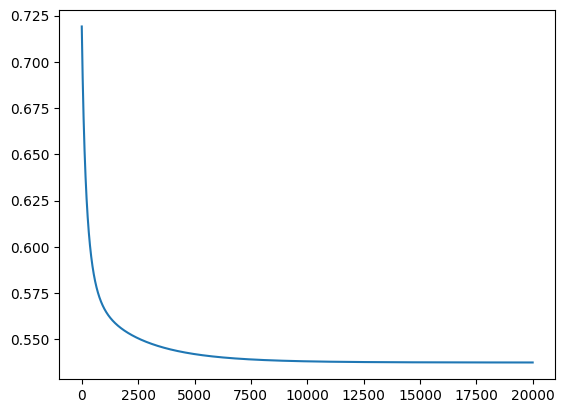

In [ ]:
import matplotlib.pyplot as plt

plt.plot([i for i in range(len(costs))] , costs)

In [483]:
from sklearn.metrics import accuracy_score

yhat_sk_model = sklearn_model.predict(X_test)
yhat_my_model = my_model.predict(X_test)

In [487]:
sk_accuracy = accuracy_score(Y_test , yhat_sk_model) 
my_accuracy = accuracy_score(Y_test , yhat_my_model)

<BarContainer object of 2 artists>

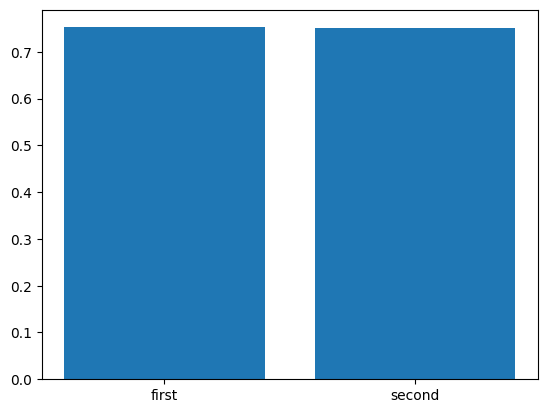

In [ ]:
plt.bar(["sk_accuracy" , "my_accuracy"] , height=[sk_accuracy , my_accuracy])